# monocle2_py tutorial: single-cell trajectory analysis

**monocle2_py** is a pure-Python re-implementation of Monocle 2, exposed
in omicverse as the `ov.single.Monocle` class (and also available
standalone as `from monocle2_py import Monocle` — same code).

This tutorial runs the full pipeline on the HSMM human skeletal-muscle
myoblast dataset — Monocle 2's canonical demo (Trapnell et al. 2014).


## 1. Setup

In [1]:
import sys
sys.path.insert(0, '/scratch/users/steorra/analysis/omicverse_dev/omicverse')

import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt

import omicverse as ov
from omicverse.single import Monocle

np.random.seed(42)
print(f'omicverse version: {ov.__version__}')

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

/scratch/users/steorra/env/CMAP/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


/scratch/users/steorra/env/CMAP/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


omicverse version: 2.1.2rc1


## 2. Load HSMM data

HSMM: 271 cells × 47 192 genes, sampled at four time points (0 / 24 /
48 / 72 h of differentiation).

In [2]:
data_dir = '/scratch/users/steorra/analysis/26_monoclepy/hsmm_data'

expr_df = pd.read_csv(f'{data_dir}/expr_matrix.csv', index_col=0)
gene_ann = pd.read_csv(f'{data_dir}/gene_annotation.csv', index_col=0)
sample_sheet = pd.read_csv(f'{data_dir}/sample_sheet.csv', index_col=0)

adata = ad.AnnData(
    X=expr_df.values.T.astype(np.float64),
    obs=sample_sheet, var=gene_ann,
)
print(f'AnnData: {adata.n_obs} cells × {adata.n_vars} genes')
adata

AnnData: 271 cells × 47192 genes


AnnData object with n_obs × n_vars = 271 × 47192
    obs: 'Library', 'Well', 'Hours', 'Media', 'Mapped.Fragments', 'Pseudotime', 'State'
    var: 'gene_short_name', 'biotype', 'num_cells_expressed', 'use_for_ordering'

## 3. Create a `Monocle` analyzer and preprocess

`Monocle` is a stateful analyzer; every method writes results back into
`mono.adata` and returns `self`, so steps can be chained.

In [3]:
mono = Monocle(adata)
mono.preprocess()  # detect_genes + size factors + dispersions
mono

Monocle(271 cells × 47192 genes)
  preprocessed: ✓

## 4. Select ordering genes

Picks high-variance genes automatically
(`dispersion_empirical > dispersion_fit`).

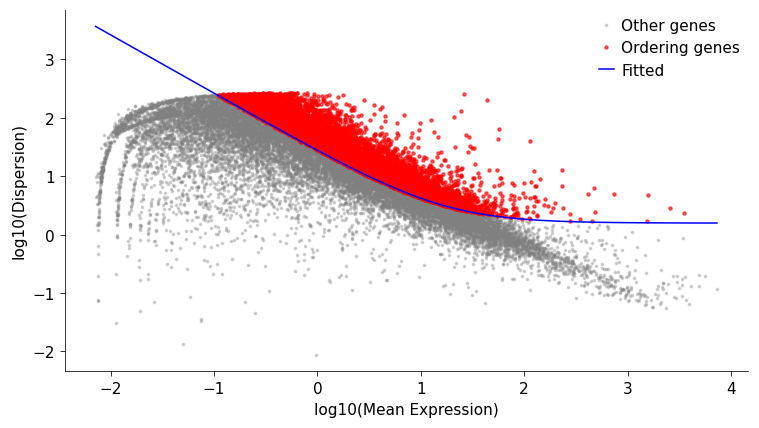

In [4]:
mono.select_ordering_genes()
mono.plot_ordering_genes(figsize=(7, 4))
plt.show()

## 5. DDRTree reduction + cell ordering

In [5]:
mono.reduce_dimension(max_components=2, verbose=True).order_cells(
    root_by_column='Hours', root_by_value=0)
print(mono)

Learning principal graph with DDRTree
  ncenter=110 for 271 cells


Iteration: 0
  Objective: 838389328.845502


Iteration: 1
  Objective: 841616100.330943
  delta_obj: 0.00384877


Iteration: 2
  Objective: 839880583.713852
  delta_obj: 0.00206212


Iteration: 3
  Objective: 840717223.816361
  delta_obj: 0.00099614
Converged!
Monocle(271 cells × 47192 genes)
  preprocessed: ✓
  ordering genes: 7817
  reduced: DDRTree
  ordered: pseudotime [0.00, 27.67], 5 states


## 6. Trajectory visualization

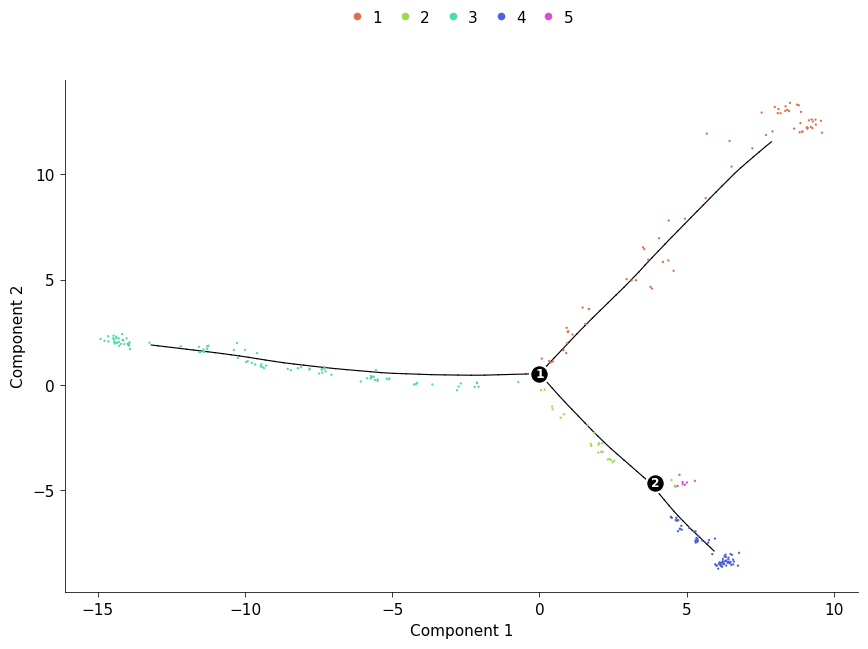

In [6]:
mono.plot_trajectory(color_by='State', cell_size=1.5)
plt.show()

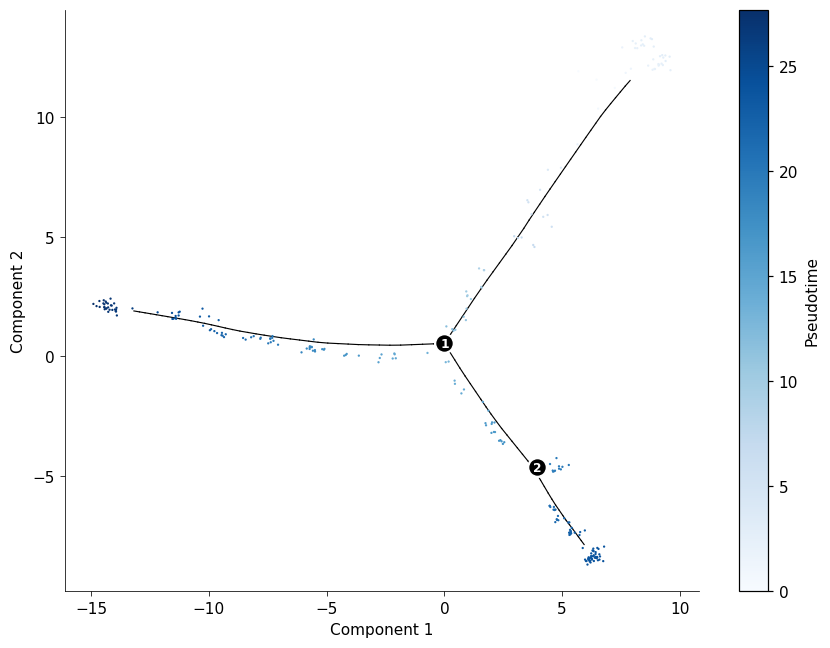

In [7]:
mono.plot_trajectory(color_by='Pseudotime', cell_size=1.5)
plt.show()

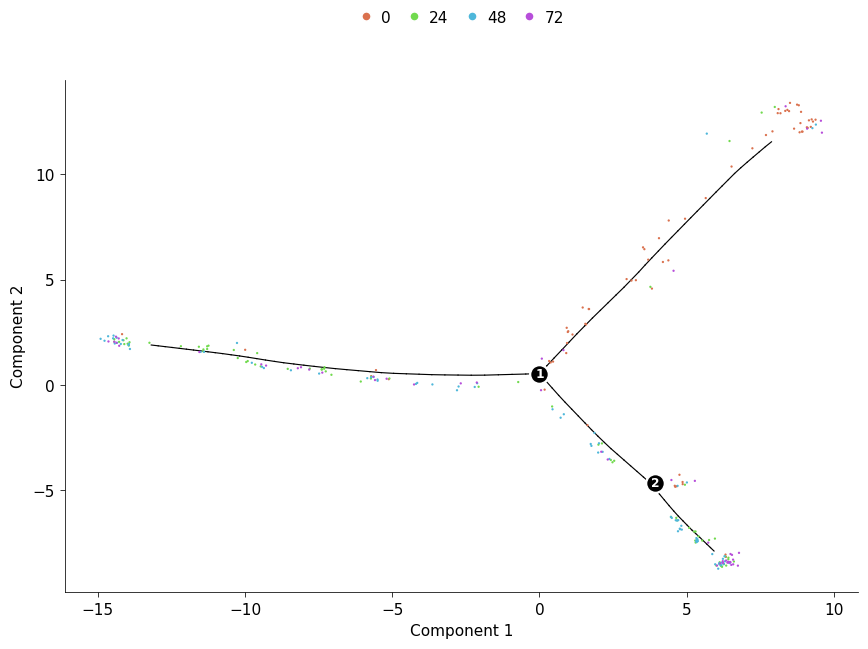

In [8]:
mono.plot_trajectory(color_by='Hours', cell_size=1.5)
plt.show()

## 7. Classical myogenic markers along pseudotime

MEF2C → ENSG00000081189.9
MYH3 → ENSG00000109063.9
MYH2 → ENSG00000125414.13
ID1 → ENSG00000125968.7


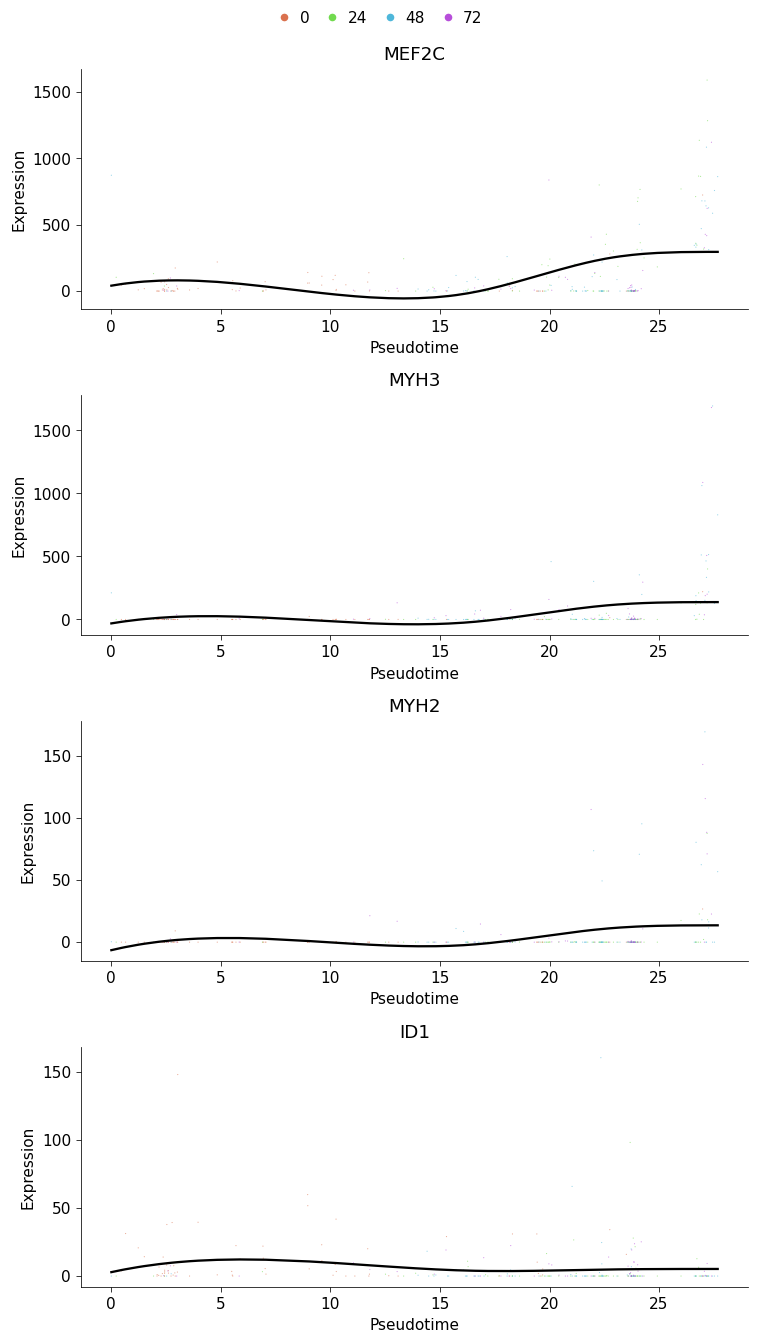

In [9]:
markers = ['MEF2C', 'MYH3', 'MYH2', 'ID1']
gene_ids = []
for g in markers:
    matches = mono.adata.var[mono.adata.var['gene_short_name'] == g].index
    if len(matches) > 0:
        gene_ids.append(matches[0])
        print(f'{g} → {matches[0]}')

mono.plot_genes_in_pseudotime(gene_ids, color_by='Hours', ncol=1, figsize=(7, 12))
plt.show()

## 8. Differential expression along pseudotime

In [10]:
# Only test expressed genes
expressed = mono.adata.var['num_cells_expressed'] >= 10
adata_expr = mono.adata[:, expressed].copy()
mono_expr = Monocle(adata_expr)  # test on subset

de = mono_expr.differential_gene_test()
sig = de[de['qval'] < 0.01]
print(f'Significant genes (qval<0.01): {len(sig)}/{len(de)}')
de.sort_values('qval').head(10)[['pval','qval','status']]

Significant genes (qval<0.01): 957/16725


                    pval  qval status
ENSG00000089685.9    0.0   0.0     OK
ENSG00000162063.8    0.0   0.0     OK
ENSG00000157456.3    0.0   0.0     OK
ENSG00000006634.3    0.0   0.0     OK
ENSG00000088325.11   0.0   0.0     OK
ENSG00000156802.8    0.0   0.0     OK
ENSG00000156970.8    0.0   0.0     OK
ENSG00000161888.7    0.0   0.0     OK
ENSG00000163535.13   0.0   0.0     OK
ENSG00000087586.13   0.0   0.0     OK

## 9. Pseudotime heatmap

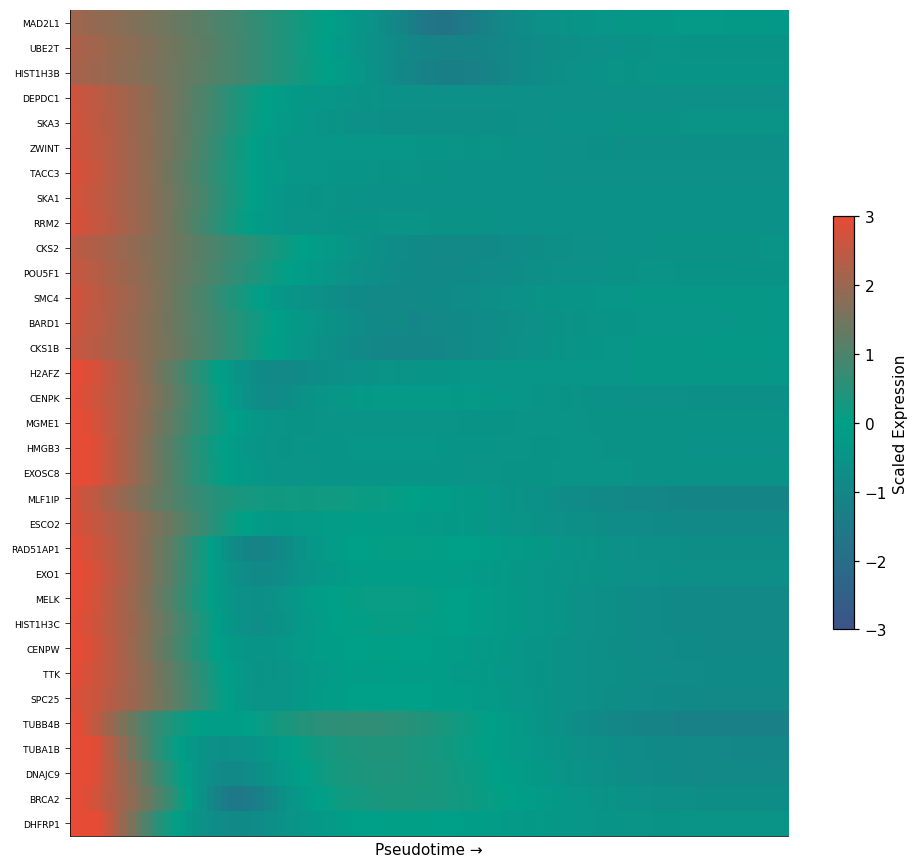

In [11]:
top50 = de.sort_values('pval').head(50).index.tolist()
mono.plot_pseudotime_heatmap(genes=top50, num_clusters=3,
                              show_rownames=True, figsize=(9, 8))
plt.show()

## Summary

Full `ov.single.Monocle` pipeline in a handful of lines:

```python
from omicverse.single import Monocle  # or: from monocle2_py import Monocle
mono = Monocle(adata)
mono.preprocess().select_ordering_genes().reduce_dimension().order_cells()
mono.plot_trajectory(color_by='State')
de = mono.differential_gene_test()
```

All results live inside `mono.adata` and stay compatible with the
scanpy / anndata ecosystem.